# INFO 264, Group Exam 2025
### Kandidate numbers: 0000, 0000, 0000, 0000
# Introduction
---
### <u>The Tasks</u>
<u>**Task 1:**</u>
* Create four machine learning models, one which have to be a neural network. The models will be used for labeling sentiment in a dataset containing hotel reviews.

<u>**Task 2:**</u>
* Create a convolutional nerual network, train it on the CIFAR-10 data set, specifically as a binary classifier on one of the categories in that data set.

# Task 1 Sentiment Analysis
---
### <u>The data</u>
The data has many columns containing data that is non-relevant for sentiment analysis. Columns with self-explainatory names, have no extra explanation.

#### <u>Non relevant data</u>
* `Hotel_Address` - String
* `Additional_Number_of_Scoring` - Unknown data value. Integer.
* `Review_Date` - String
* `Average_Score` - The hotels avarage score. Float
* `Hotel_Name` - String
* `Reviewer_Nationality` - String
* `Review_Total_Negative_Word_Counts` - Amount of words in a negative review. Integer
* `Total_Number_of_Reviews` - Amount of reviews for a given hotel. Integer
* `Review_Total_Positive_Word_Counts` - Amount of words in a positive review. Integer
* `Total_Number_of_Reviews_Reviewer_Has_Given` - Amount of reviews from user. Integer
* `Tags` - List of strings
* `Days_since_review` - String
* `lat` - Float
* `lng` - Float

It is important to note that this data is not relevant for our task, but could be useful for other sentiment tasks. Like if we were to expand our task we could see if the hotel had important value or nationality of the reviewer.

#### <u>Relevant data</u>
* `Negative_Review` - Review labeled as negative. String
* `Positive_Review` - Review labeled as positive. String
* `Reviewer_Score` - Score left by the reviewer. Float

Many reviews had both positive and negative labeled reviews, which has to be combined in order to analyse the whole sentiment left by the reviewer.
 

### <u>Preprocessing steps</u>
#### <u>Preprocessing setp 1. Data extraction</u>
`extract_relevant_csv_data()` extracts relevant and returns a pandas datafram of the data. We clean this data thoroughly later.

In [45]:
import pandas as pd

def extract_relevant_csv_data(_file_path, _use_cols = ["Negative_Review", "Positive_Review", "Reviewer_Score"]):
    _dataset = pd.read_csv(_file_path, usecols = _use_cols)
    _new_dataset = []
    for i in _dataset.to_numpy():
        _new_dataset.append({"Reviewer_Score": i[2], "Positive_Review": i[0], "Negative_Review" : i[1]})
    return pd.DataFrame(_new_dataset)
data = extract_relevant_csv_data("./data/Hotel_Reviews.csv")
data # To display the data below

,Reviewer_Score,Positive_Review,Negative_Review
0,2.9,I am so angry that i made this post available...,Only the park outside of the hotel was beauti...
1,7.5,No Negative,No real complaints the hotel was great great ...
2,7.1,Rooms are nice but for elderly a bit difficul...,Location was good and staff were ok It is cut...
3,3.8,My room was dirty and I was afraid to walk ba...,Great location in nice surroundings the bar a...
4,6.7,You When I booked with your company on line y...,Amazing location and building Romantic setting
...,...,...,...
515733,7.0,no trolly or staff to help you take the lugga...,location
515734,5.8,The hotel looks like 3 but surely not 4,Breakfast was ok and we got earlier check in
515735,2.5,The ac was useless It was a hot week in vienn...,No Positive
515736,8.8,No Negative,The rooms are enormous and really comfortable...


#### <u>Preprocessing step 2. Cleaning</u>
`combine_reviews()` is the main function for cleaning. It looks at each review and clean them to remove unwanted special characters, numbers, single character, multiple spaces, convert to losercase, lemmatize and remove stopwards. This happens to give the model consistent text, remove unnecessary noise and to decrease vocabulary.

##### <u>Deeper explanation</u>
* Semantic meaning:
    * The purpose of our cleaning is to remove words or characters that won't have semantic meaning for the review. Additionaly it makes our vocabulary much more simple for our model, instead of looking at "room!" and "room?" seperate. The model would also be more effcient and simpler. We recognize the importance of a decent size vocabulary, but having one word take up more than it needs seemed unnecessary. We should also mention that some special characters, like emojis or writing in all caps, can carry sentiment value, but could lead to unreliable results. The dataset doesn't have enough present that implementing these scenarios would effect the results. Furthermore it is important to note that removing prefixes can change the meaning of some words which could effect the result, we also found this substantial.

* Tokenization:
    * By removing multiple spaces to one spaces we prepare our text for a consistent tokenization before training. By leaving them we could have empty tokens in our data.

* Stopwords
    * `"stopwords"` is a standardized list of words that don't carry much refenential meaning. But some words in the list like pronouns, subjuctions, etc. are arguably important for language analysis. In our case we chose not to put much weight on how the review is structurized. As it requires a much more complex model and we believe that referential words would not give us good enough value. Also we believe that the reviewer are more likely to use adjectives to complain or praise the hotel. With this focus we can remove the structural words. When using `"stopwords"` it could also remove or change sentiment value in the review, but due to our assumptions we believe it will have little impact on the results. Lastly we will also see a smaller memory footprint, faster training, improved understanding to frequent words and reduce overfitting by using this list.

* Lemmatizing words
    * Lemmatizing reduces our words to their base origin in the dictionary. For example will "connect", "connection", "connecting", etc be turned into "connect" since the words all have origin in "connect". Our argument for lemmatizing is similar to stopwords. As we assume the different forms of words will have similar value so we can get a good statistcal analysis by treating them as one word. Lemmatizing will always provide valid words, as well as consider context. This is opposed to stemming which can produce words of little value, and it does not look at context, hence why we don't use it at all. Lemmatization do cost more computational cost compared to stemming but is worth the cost. We used `WordNetLemmatizer` downloaded from `NLTKs` wordnet. 

##### <u>Side note</u>
We discussed to include duplicates but chose not to, because it lacked unique identifiers in the data so it would impossible to verify if there are two duplicates. In addition we added a threshold to tell us if a review is positive, neutral or negative, you can see this in `target_score_to_expression`. Even with these thresholds the data is still imbalanced. We come back to how this impacted our models in the conclusion.

In [46]:
# The clean_sentences function has been heavily inspired by "https://stackabuse.com/_text-classification-with-python-and-scikit-learn/" text processing.
 
# import nltk # Needed to download "stopwords" and "wordnet"
# nltk.download('stopwords') # Trenger bare å kjøre første gang
# nltk.download('wordnet') # Trenger bare å kjære første gang
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
import re
from nltk.stem import WordNetLemmatizer

# An indenpendent function that cleans the sentences up.
# Returns a list of the cleansed sentences, and the data variable which was used.
def clean_sentences(_data_combined):
    _texts = []
    for _text_pre in range(0, len(_data_combined)):
        # Remove all the special characters
        _text = re.sub(r"\W", " ", str(data.iloc[_text_pre]))
        # Remove all numbers
        _text = re.sub(r"\d", " ", _text)
        # remove all single characters
        _text = re.sub(r"\s+[a-zA-Z]\s+", " ", _text)
        # Remove single characters from the start
        _text = re.sub(r"\^[a-zA-Z]\s+", " ", _text) 
        # Substituting multiple spaces with single space
        _text = re.sub(r"\s+", " ", _text, flags = re.I)
        # Removing prefixed "b"
        _text = re.sub(r"^b\s+", "", _text)
        # Lemmatization
        _text = _text.split()
        # Converting to Lowercase
        for _word in range(len(_text)):
            _text[_word] = _text[_word].lower()
        _text = [WordNetLemmatizer().lemmatize(_word) for _word in _text if _word not in stop_words]

        _text = " ".join(_text)

        _texts.append(_text)
    return pd.array(_texts)

def combine_reviews(_data):
    X_neg, X_pos = clean_sentences(_data["Negative_Review"]), clean_sentences(_data["Positive_Review"])
    X = []
    labels_to_remove = []
    for n in range(len(X_neg)):
        if X_neg[n] in (None, "", "negative") and X_pos[n] in (None, "", "positive"):
            # Append the number when the review is useless, so we can remove it's label.
            labels_to_remove.append(n)
        else:
            if X_neg[n] in (None, "", "negative"):
                X.append(X_pos[n])
            elif X_pos[n] in (None, "", "positive"):
                X.append(X_neg[n])
            else:
                X.append(X_neg[n] + " " + X_pos[n])
    return pd.array(X), labels_to_remove

def target_score_to_expression(_data, none_labels):
    _scores_pre = _data["Reviewer_Score"].values
    _scores = []
    for n in range(len(_scores_pre)):
        if n not in none_labels:
            if _scores_pre[n] < 6:
                _scores.append("negative")
            elif _scores_pre[n] < 8:
                _scores.append("neutral")
            else:
                _scores.append("positive")
        
    return pd.array(_scores, dtype = "object")

### Model preprocessing steps
To get a better understanding of our models we decided to use the same metric over all models where it is possible, we chose `accuracy` since it gives the most optimal model. All of our models uses the same data, but preprocesses it differently to better fit each model.

1. <u> The first three models</u>
* Uses `X` and `y` from `combine_reviews()` to get our reviews and labels.

2. <u>The LSTM model uses the following:</u>
* Use `one_hot_encode()` to convert `y` into one-hot encoded labels, ex. `[0, 1, 0]`. This is done to better represent the labels when training the model, and to standardize text and reduce noise.
* Since we one-hot encoded the labels we can also use loss function categorical_crossentropy.
* We also tokenize our reviews using Keras ``Tokenizer``.

3. <u>The KNN model uses the following:</u>
    * Start by converting the labels_LSTM, one-hot encoded labels, into 0, 1 or 2 which better fit this model.
    * Here we also use a tokenizer but here we use sklearn's ``TfidfVectorizer``.

4. <u>The NLP model uses the following:</u>
    * Here we use the `y` as is, for a more readable approach.
    * In addition we use a `CountVectorizer` to turn our `review_strings` to a fitted `bag_of_words` for our model which you will see below.

5. <u>The CNN model uses the following:</u>
    * Start like our LSTM and create one-hot encoded labels.
    * Clean the data seperatly from the other models, but clean as we did for the others.
    * When it comes to how we vectorize we explain it quite deeply further below.

### b) Models
##### When building our LSTM model and how to preprocess we used this repository as a guideline to create a suitable model for our task: "https://github.com/sergiovirahonda/TweetsSentimentAnalysis/blob/main/TweetsSentimentPredictions.ipynb"

In [47]:
# All the imports needed for our models
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
import tensorflow as tf
import warnings
from gensim.models import Word2Vec;
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras import layers, datasets, models, callbacks
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from typing import Iterable
warnings.filterwarnings('ignore')

In [48]:
# Prepare the data, target and clean it.
X, none_labels = combine_reviews(data)
y = target_score_to_expression(data, none_labels)
data = None # Dereferencing for garbage collection
# 2m 30s

In [49]:
# One-hot encode the labels
def one_hot_encode(y_data):
    labels = np.array(y_data)
    y_data = []
    for i in range(len(labels)):
        if labels[i] == 'neutral':
            y_data.append(0)
        if labels[i] == 'negative':
            y_data.append(1)
        if labels[i] == 'positive':
            y_data.append(2)
    y_data = np.array(y_data)
    labels = tf.keras.utils.to_categorical(y_data, num_classes = 3)
    return labels

# Bør kanskje ha dette med for å forklare hvor vi får parametrene våre fra, usikker om vi bør ha med koden.

In [50]:
# ===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Med fullført preprocessing så har vi følgende mengde ord:
# 10331478 ord
# 73439 unike ord
# 18941 ord forekommer 5 ganger eller mer
# 95% av reviews er 55 ord eller færre 
# ===================================================================

#### LSTM Model

Since we had to use a neural network we chose the recomended one which was LSTM. We have tried and failed many times with this model, but with a little guideline we have created a very optimal solution to the task. As we change weights based on accuracy it will most likely be the best model. In addition it is quite more powerful than some of the other models we have used.

For faster training, we have opted to use tensorflow with a GPU.

In [51]:
labels_LSTM = one_hot_encode(y)

max_words = 5000
max_len = 55

# Tokenize and pad the data.
tokenizer = Tokenizer(num_words = max_words)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
reviews = pad_sequences(sequences, maxlen = max_len)

X_train_LSTM, X_test_LSTM, y_train_LSTM, y_test_LSTM = train_test_split(reviews, labels_LSTM, random_state = 0)

#### Training the LSTM model

We add an ``Embedding`` with the ``max_words`` since this is how many features we have in our tokeinzer. Next we add a ``Masking`` with the ``mask_value`` set to 0 to skip any timestep equal to the ``mask_value``. Then a layer with 20 units of ``LSTM`` with a ``dropout`` of 0.3 to prevent overfitting. We use the ``activation="relu"`` since this activation is efficient and works nicely with sentiment analysis. In our last layer we create an output layer with 3 ``Dense`` units with an ``activation="softmax"`` since we mostly want a prediction percentage than a float value between for example -200 and 200. In our compiler we use an ``optimizer="rmsprop"`` which works quite nicely with our task, in addition we look at out ``loss`` based on the `categorical_crossentropy` which is the best loss method for our task with 3 outputs with ``one-hot encoders``. As we said earlier we use the metric `accuracy` to train our model to be the best. In addition we add a `ModelCheckpoint` to save the best model we got under our training. We also have an`` early_stopping`` method that stops the epochs if ``val_loss`` does not improve over 5 epochs.

In [52]:
with tf.device('/GPU:0'):
    model_LSTM = Sequential()
    model_LSTM.add(layers.Embedding(max_words, 20))
    model_LSTM.add(layers.Masking(mask_value = 0))
    model_LSTM.add(layers.LSTM(20, dropout = 0.3, activation = 'relu'))
    model_LSTM.add(layers.Dense(3, activation = 'softmax'))
    model_LSTM.compile(optimizer = 'rmsprop', loss = 'categorical_crossentropy', metrics = ['accuracy'])

    early_stopping = callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)

    # Implementing model_LSTM checkpoins to save the best metric and do not lose it on training.
    checkpoint_LSTM = ModelCheckpoint("best_model.keras", monitor = 'val_accuracy', verbose = 1, save_best_only = True, mode = 'auto', save_weights_only = False)
    history_LSTM = model_LSTM.fit(X_train_LSTM, y_train_LSTM, epochs = 50, batch_size = 256, validation_data = (X_test_LSTM, y_test_LSTM), callbacks = [checkpoint_LSTM, early_stopping])
# 17m 10s

Epoch 1/50
1509/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6657 - loss: 0.7611
Epoch 1: val_accuracy improved from -inf to 0.70577, saving model to best_model.keras
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.6657 - loss: 0.7610 - val_accuracy: 0.7058 - val_loss: 0.6448
Epoch 2/50
1510/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7105 - loss: 0.6396
Epoch 2: val_accuracy improved from 0.70577 to 0.72013, saving model to best_model.keras
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7105 - loss: 0.6396 - val_accuracy: 0.7201 - val_loss: 0.6221
Epoch 3/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7167 - loss: 0.6248
Epoch 3: val_accuracy did not improve from 0.72013
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7167 - loss: 0.6248 - val_accuracy: 0.7190 - val_loss: 0.6190
Epoch 4/50
1510/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7219 - loss: 0.6154
Epoch 4: val_accuracy did not improve from 0.72013
1511

In [53]:
# Load the best model obtained during training
best_model_LSTM = keras.models.load_model("best_model.keras")

In [54]:
# Evaluate the model and print out the accuracy.
test_loss_LSTM, test_acc_LSTM = best_model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose = 2)
print('Model accuracy: ', test_acc_LSTM)

4030/4030 - 12s - 3ms/step - accuracy: 0.7260 - loss: 0.6034
Model accuracy:  0.725970447063446


4030/4030 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step


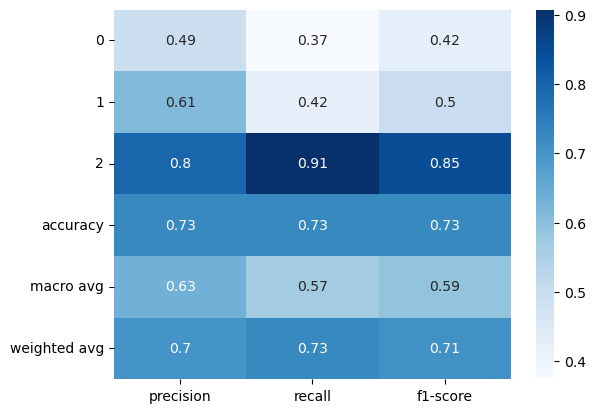

In [55]:
# Create a classification report and use seaborn to show it.
predictions_LSTM = best_model_LSTM.predict(X_test_LSTM)
clf_report_LSTM = classification_report(np.argmax(y_test_LSTM, axis = 1), np.argmax(predictions_LSTM, axis = 1), output_dict = True)

fig, ax = plt.subplots(1,1)
sns.heatmap(pd.DataFrame(clf_report_LSTM).iloc[:-1, :].T, annot=True, cmap="Blues", ax=ax)
fig.savefig('./matplotlib_data/class_rep_lstm')

4030/4030 - 11s - 3ms/step - accuracy: 0.7260 - loss: 0.6034


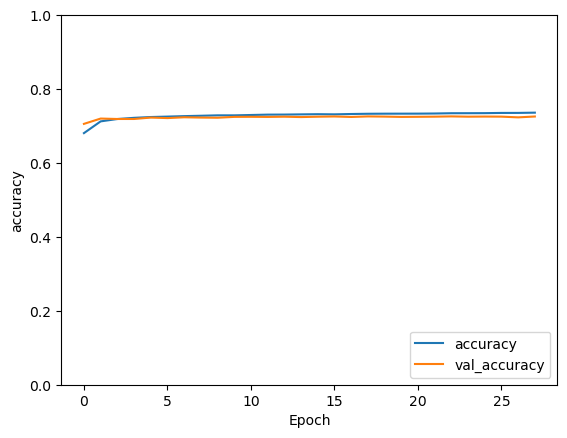

In [56]:
# Create a graph to check overfitting and underfitting.
plt.plot(history_LSTM.history['accuracy'], label='accuracy')
plt.plot(history_LSTM.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss_LSTM, test_acc_LSTM = best_model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose=2)
fig.savefig('./matplotlib_data/over_lstm')

#### KNN Model
When we first started testing our KNN model we used different data than our other models. But after careful consideration we wanted to use the same data over all models. Therefore we needed to find a vectorizer which could help convert the sentences to vectors. After testing we found sklearn's `TfidfVectorizer` to be the best fit. We use some of the same parameters as our `Tokenizer` in the LSTM. Only difference is that the words also have to be in five different reviews.

We evaluate the data with both a classification report, confusion matrix and calculation of overfitting.

Source: https://www.geeksforgeeks.org/understanding-tf-idf-term-frequency-inverse-document-frequency/

In [57]:
# Convert the one-hot encoded labels to a 1D array.
labels_convert_KNN = one_hot_encode(y)
labels_convert_KNN = np.argmax(labels_convert_KNN, axis=1)

In [58]:
# Vectorizing the reviews, we use the same features as our tokenizer in the LSTM model.
vectorizer = TfidfVectorizer(max_features = 5000, ngram_range = (1, 1), min_df = 5)
vectorize_reviews = vectorizer.fit_transform(X) 

In [59]:
# Split the data into training and testing sets. Testing on 20% of the data with a random state at 42 because that's the answer to life, the universe, and everything
X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(vectorize_reviews, labels_convert_KNN, test_size = 0.2, random_state = 42)

In [60]:
# After a lot of time we found that KNN is a higly inneficient method compared to the other models. More details on this in the conclution.
k = 13
model_KNN = KNeighborsClassifier(n_neighbors = k)
model_KNN.fit(X_train_KNN, y_train_KNN)
y_pred_train = model_KNN.predict(X_train_KNN)
y_pred_test = model_KNN.predict(X_test_KNN)
# 67m 49s

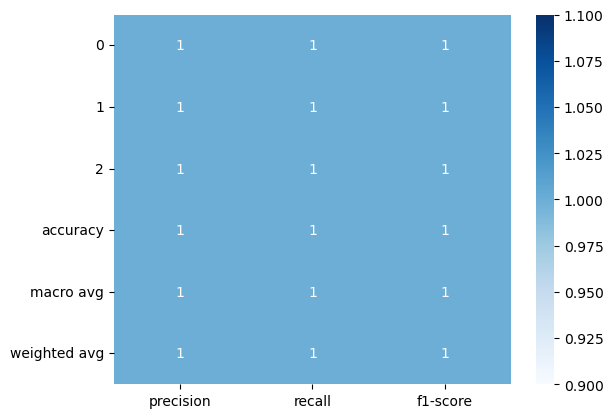

In [61]:
# Creating a classification report
y_pred_KNN = model_KNN.predict(X_test_KNN)
clf_report_KNN = classification_report(y_test_KNN, y_test_KNN, output_dict = True)

fig, ax = plt.subplots(1,1)

# Create a classification report and use seaborn to show it.
sns.heatmap(pd.DataFrame(clf_report_KNN).iloc[:-1, :].T, annot = True, cmap = "Blues", ax=ax)
# 13m 33s
fig.savefig('./matplotlib_data/class_rep_cnn')

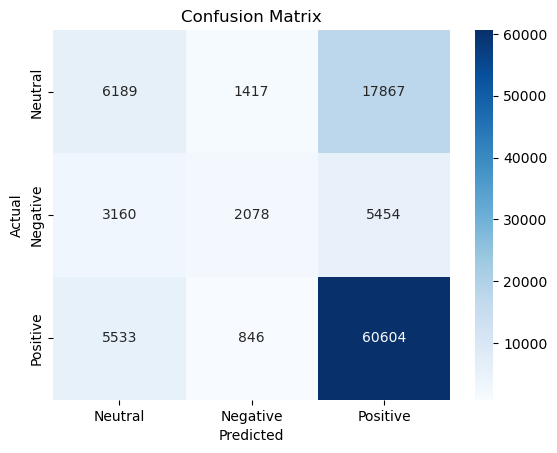

In [62]:
# Creating a confusion matrix
matrix_KNN = sklearn.metrics.confusion_matrix(y_test_KNN, y_pred_KNN)

sns.heatmap(
    matrix_KNN, annot = True, fmt = 'd', cmap = 'Blues',
    xticklabels = ['Neutral', 'Negative', 'Positive'],
    yticklabels = ['Neutral', 'Negative', 'Positive']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

fig.savefig('./matplotlib_data/conf_mat_knn')

Training Accuracy: 0.7086332678930658
Testing Accuracy: 0.6676910846550588

Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.24      0.31     25473
           1       0.48      0.19      0.28     10692
           2       0.72      0.90      0.80     66983

    accuracy                           0.67    103148
   macro avg       0.54      0.45      0.46    103148
weighted avg       0.62      0.67      0.63    103148



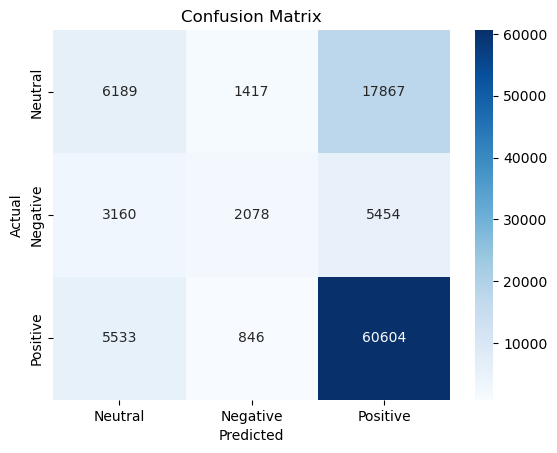

In [63]:
# Creating a graph to check over/under-fitting
print("Training Accuracy:", accuracy_score(y_train_KNN, y_pred_train))
print("Testing Accuracy:", accuracy_score(y_test_KNN, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test_KNN, y_pred_test))

conf_matrix = confusion_matrix(y_test_KNN, y_pred_test)
sns.heatmap(
    conf_matrix, annot = True, fmt = 'd', cmap = 'Blues',
    xticklabels = ['Neutral', 'Negative', 'Positive'],
    yticklabels = ['Neutral', 'Negative', 'Positive']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### NLP Model

We use this model since Natural Language Processing models are widely used when tackling sentiments analysis.

As per "Zubair Ashfaque" from "https://medium.com/@zubairashfaque/sentiment-analysis-with-naive-bayes-algorithm-a31021764fb4":  

__Sentiment Analysis with the Naive Bayes algorithm is a powerful approach, using probability and linguistic analysis to categorize text sentiments as positive, negative, or neutral. By preprocessing text, calculating log priors, and deriving log-likelihoods, this method quantifies sentiment, guiding accurate classification.__

<br>

After doing some testing with both `MultinomialNB` and `BernoulliNB` we found that `MultinomialNB` had the best accuracy with our data which is our score metric to our models. In addition we also experimented with `CountVectorizer` and `TfdifVectorizer` and found that `CountVectorizer` was a better fit with the data to get the most accurate model. Even though `TfdifVectorizer` was better overall at finding positive reviews.

In [64]:
# Since the dataset is so huge, we use the 5000 of the most common words, and we want to use the words that contains in at least 5 reviews. In addition we use words
# that are in a maximum of 60% of our reviews to remove non meaningful words.
cv = CountVectorizer(max_features = 5000, min_df = 5, max_df = 0.6)
X_nlp = cv.fit_transform(X)

X_train_NLP, X_test_NLP, y_train_NLP, y_test_NLP = train_test_split(X_nlp, y, test_size = 0.2, random_state = 42)

In [65]:
# Train the model
print("MultinomialNB:")
nlp_model = MultinomialNB()
nlp_model.fit(X_train_NLP, y_train_NLP)

MultinomialNB:


MultinomialNB()

{'negative': {'precision': 0.4023205002636932, 'recall': 0.4994388327721661, 'f1-score': 0.4456499061130816, 'support': 10692.0}, 'neutral': {'precision': 0.4178254254679263, 'recall': 0.4635888980489145, 'f1-score': 0.43951913056423997, 'support': 25473.0}, 'positive': {'precision': 0.8261539959748101, 'recall': 0.7599092307003269, 'f1-score': 0.7916481978303977, 'support': 66983.0}, 'accuracy': 0.6597316477294761, 'macro avg': {'precision': 0.5487666405688099, 'recall': 0.5743123205071359, 'f1-score': 0.5589390781692397, 'support': 103148.0}, 'weighted avg': {'precision': 0.6813816163584809, 'recall': 0.6597316477294761, 'f1-score': 0.6688227677152973, 'support': 103148.0}}


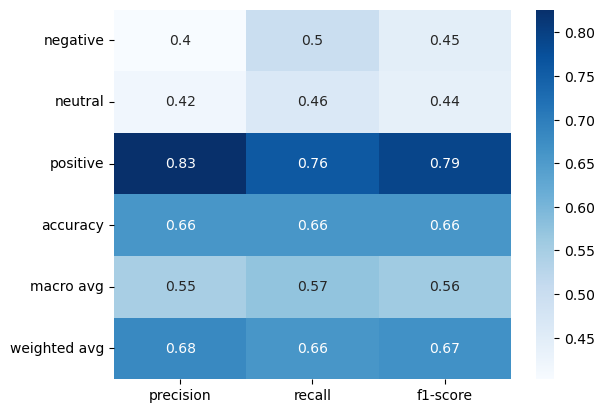

In [66]:
# Creating a classification report
y_pred_nlp = nlp_model.predict(X_test_NLP)
clf_report_NLP = classification_report(y_test_NLP, y_pred_nlp, output_dict = True)
print(clf_report_NLP)

fig, ax = plt.subplots(1,1)
sns.heatmap(pd.DataFrame(clf_report_NLP).iloc[:-1, :].T, annot = True, cmap = "Blues", ax=ax)
fig.savefig('./matplotlib_data/class_rep_nlp')

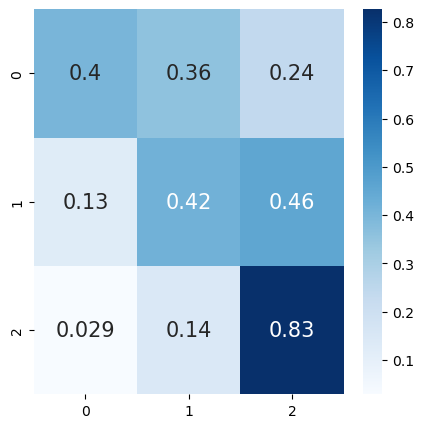

In [67]:
# Creating a confusion matrix
matrix_nlp = sklearn.metrics.confusion_matrix(y_pred_nlp, y_test_NLP)

conf_matrix = pd.DataFrame(matrix_nlp, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix = np.array(conf_matrix).astype('float') / np.array(conf_matrix).sum(axis = 1)[:, np.newaxis]
plt.figure(figsize = (5,5))
sns.heatmap(conf_matrix, annot = True, annot_kws = {"size": 15}, cmap = "Blues")
fig.savefig('./matplotlib_data/conf_mat_nlp')

#### CNN Model

##### <u>Vectorization</u>

The words are then converted to vectors to reduce processing time. The function `dataset_vectorization()` is used for this. The word-vectors cannot have just one channel with the word encoded into a number as an id representing it because of how gradient descent works. The neural network uses gradient descent, which assumes that the function is continuous, that the output interpolates smoothly between two input vectors, as the values of one vector interpolate into the other vector. This excludes id encoding, because words with ids close to each other are not at all guarranteed to have similar meanings, and for one dimension, it is basically impossible as the set of words grows, given that words have many "axies" of meaning.

One-hot encoding won't work either:
1. Because it would require a number of channels for the word-vector equal to the number of words. This excludes this approach because of how much memory and processing time it would require.

2. Because the input vectors would be far to sparse with meaning to draw anything out of, which is why this encoding style isn't used for these kinds of networks. //// SOURCE

One solution to this is turning the words into vectors using a system that can somehow figure out commonalities between the words or how they relate to each other or any kind of pattern, and then figure out a number of "axies" of meaning for each word. One such system is implemented by the `Word2Vec` class in `gensim`. It takes a model for vectorization and trains itself according to the model and a set of words provided. After this, a word can be inputted to the Word2Vec instance, and it will return an array of values. This array is the vector we use to represent the word, which we feed into the network. //// SOURCE

After this step, the array structure should look something like this:
```python
datasetX: [ [ [ float32, ... (k) ], ... (m) ] ... (n) ]
```
where `n` is the number of reviews, `m` is the length of the review, and `k` is the dimension of the word-vector.

We see that the reviews may have varying numbers of words, meaning that the arrays of word vectors would vary in length. To feed the array into the network, it needs to be converted to a tensor. The problem is that tensors are required to be like transcendentally rectangular, and the arrays of words varying in length is not comaptible with that. We did assume that a CNN with a convolutional layer as the input would be able to account for this, since the layer just strides from one end of the texture to the other, but apparently tensorflow doesn't like that.

# ==== IVAN Er dette riktig? =====
To solve this, I just padd the reviews to the length of the longest review, with word vectors where all the numbers are 0. This should be fine, since the vectorizer makes word vectors with values from -1 to 1, so 0 would be neutral; that the word vector has no meaning on that axis.
# ========================

The number of fragment channels was chosen based on testing. A larger number of channels consistently gave better results, and we assume that this trend would probably continue up until a number of channels that is some larger fraction of the total number of unique words in all the reviews, but more channels increases memory usage and training time, so we never really got to test this theory on the entire dataset. We assume that as the number of channels reaches past a quarter of all the unique words, the network would start to perform worse, since there would be too many channels and not enough words to generate meaning, leading to a similar situation as the one-hot encoding, that when it equals to the number of unique words, it would be equivalent to be like a padded out one-hot encoding. Again, we didn't get to actually test the one hot encoding, and we didn't get to test larger numbers of channels, so we can't really show data to attest to this theory.


##### <u>Defining the model</u>

The model uses a convolutional layer as input. The size and stride length of the filters was chosen based on testing. We found that these values were the ones that gave the best results. //// DOUBLE CHECK THIS: // A to small of a filter didn't perform very well. We theorize that this is because words in a sentence relate to each other across larger distances in a stream of speech or text, so a wider filter would do better. What we also saw was that when the filter was too large, it performed worse. We theorize that this is because words that are to far appart, don't mean much for each other, at least not as much as words that are close to each other, so they would mostly just be noise in the filter.

The 1D convolutional layer, gives a 2D output because there is a neuron for each channel of the fragments in the texture, so there is 1 dimension from the fragment channels and 1 dimension from the convolutional layer dimensionality. We use a flatten layer after the convolutional layer to turn the 2D output of the layer into a 1D output. All the outputs are kept in tact, just sequenced into a line.

We use a couple more layers after the convolutional layer to properly interpret the output of it and narrow it down to the three categories:
* positive 
* neutral
* negative

We use dropout layers in between the other layers, because by disregarding some of the inputs from one layer to the next, it makes the network more resilient. If a layer can't rely on the value of a neuron to always be usable, it has to find other patterns to reinforce, which makes the network spread the pattern recognition wider across the neurons in the layer.
//// SOURCE: https://medium.com/@utsavraj.ptn04/dropping-the-knowledge-bomb-understanding-dropout-layers-in-deep-learning-0612f517269d

The model uses early stopping in relation to loss. This is because if the model starts to perform worse with training, it is important to stop it when it is close to its peak. We have given the model a higher patience value, this is because we wanted it to try a little harder before giving up. This relates to the graphs that we saw, where accuracy tended to have some ups and downs, so the model should be a little more cool and levelheaded and hold the stocks a little longer. Also it was a bit sad to see the model give up after 10 out of 50 epochs.


In [68]:
#############
# DATAFRAME CONVERZZION
import pandas as pd

def dataframe_convertion(_dataset):
    _merged_reviews = []
    for i in _dataset.to_numpy():
        _merged_reviews.append({ "score": i[2], "review": i[0] + " " + i[1] })
    
    return _merged_reviews

In [69]:
#############
# DATASET EXTRAXXION

from typing import Iterable

def entry_extraction(_entry, _col):
    _entry_extract = []
    if isinstance(_entry[_col], Iterable):
        for _word in _entry[_col]:
            _entry_extract.append(_word)
        return _entry_extract
    else:
        return _entry[_col]

def dataset_extraction(_dataset, _col):
    _dataset_extract = []
    for _entry in _dataset:
        _entry_extract = entry_extraction(_entry, _col)
        _dataset_extract.append(_entry_extract)
    return _dataset_extract

In [70]:
#############
# DATASET PREPARATION

import re
import nltk

def string_clean(_string):
    _string = _string.lower()
    _string = re.sub(r"\d+", "", _string)
    _string = re.sub(r"[^\w\s]", "", _string)
    return _string

def lemma_string(_string):
    _text = nltk.word_tokenize(_string)
    _text_lemma = []
    for _word in _text:
        _word_lemma = WordNetLemmatizer().lemmatize(_word)
        if not _word_lemma in stop_words:
            _text_lemma.append(_word_lemma)
    return _text_lemma

def dataset_preparation(_dataset, _mode = "lemma"):
    _dataset_prepare = []
    _entry_longest = 0
    if _mode == "lemma":
        for _review in _dataset:
            _review_prepare = { "score": _review["score"], "review": lemma_string(string_clean(_review["review"])) }
            _dataset_prepare.append(_review_prepare)
            if len(_review_prepare["review"]) > _entry_longest:
                _entry_longest = len(_review_prepare["review"])
    else:
        raise ValueError("provided preparation mode does not exist")

    return _dataset_prepare, _entry_longest

In [71]:
#############
# SCORE: (abstract python decimal number) TO LABEL CONVERZZION

const_label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2,
}

const_score_map = {
     0: 0,
     1: 0,
     2: 0,
     3: 0,
     4: 0,
     5: 0,
     6: 0,
     7: 1,
     8: 1,
     9: 2,
    10: 2,
}

def entry_label_convertion( _score ):
    return const_score_map[round(_score)]

In [72]:
#############
# DATASET SPLITTING / VECTORIZATION

import random
import numpy as np

# im doing it like this because it saves memory,
# doing it seperately uses twice as much memory at its peak

def dataset_vectorize_slash_split(_dataset_X, _dataset_Y, _ratio_test, _channels, _resolution, _categories, _model):
    _dataset_length = len(_dataset_X)
    if len(_dataset_Y) != _dataset_length:
        raise ValueError("cannot split dataset provided dataset components do not have the same length.")
        
    _test_length = round(len(_dataset_X) * _ratio_test)
    _train_length = _dataset_length - _test_length
    
    _train_X = np.zeros((_train_length, _resolution, _channels), dtype = np.float32)
    _train_Y = np.zeros((_train_length, _categories), dtype = np.float32)
    _test_X = np.zeros((_test_length, _resolution, _channels), dtype = np.float32)
    _test_Y = np.zeros((_test_length, _categories), dtype = np.float32)

    i = 0
    j = 0
    k = 0
    while i < _test_length:
        if len(_dataset_X) <= 0:
            break
        
        _random_index = random.randint(0, len(_dataset_X) - 1)

        _entry = _dataset_X.pop(_random_index)
        _entry_length = len(_entry)
        j = 0
        while j < _resolution and j < _entry_length:
            _word = _entry[j]
            if _word in _model.wv:
                _word_vecc = _model.wv[_word]
                k = 0
                while k < _channels:
                    _test_X[i][j][k] = _word_vecc[k]
                    k += 1
            j += 1
        
        _value = _dataset_Y.pop(_random_index)
        _test_Y[i][entry_label_convertion( _value )] = 1

        i += 1

    i = 0
    j = 0
    k = 0
    while i < _train_length:
        if len(_dataset_X) <= 0:
            break
        
        _random_index = random.randint(0, len(_dataset_X) - 1)

        _entry = _dataset_X.pop(_random_index)
        _entry_length = len(_entry)
        j = 0
        while j < _resolution and j < _entry_length:
            _word = _entry[j]
            if _word in _model.wv:
                _word_vecc = _model.wv[_word]
                k = 0
                while k < _channels:
                    _train_X[i][j][k] = _word_vecc[k]
                    k += 1
            j += 1

        _value = _dataset_Y.pop(_random_index)
        _train_Y[i][entry_label_convertion( _value )] = 1
    
        i += 1
    
    return _train_X, _test_X, _train_Y, _test_Y

In [73]:
import psutil

""" does the data very thoroughly, really properly does it

does data to following format:

n = number of reviews
m = number of words in review
k = number of channels per vectorized word

      dataset: [ entry, ... (n) ]
        entry: { "review": texture, "score": socre }
      texture: [ fragment, ... (m) ]
     fragment: [ colourChannel, ... (k) ]
colourChannel: float32
        score: [ boolean, boolean, boolean ]

dataset: [ [ [ [ float32, ... (k) ], ... (m) ], [ boolean, boolean, boolean ] ] ... (n) ]

datasetX: [ texture ... (n) ]
datasetY: [ score ... (n) ]

"""
def do_data(_path, _preparation_mode = "lemma", _fragment_channels = 100, _vectorization_mode = "skip", _pad_vectors = False):
    if _vectorization_mode != "skip" and _vectorization_mode != "bow":
        raise ValueError("provided vectorization mode does not exist")

    _10_power_2 = 1024
    _python = psutil.Process()
    print("  >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))

    print("  # # started preparation")
    
    print("        # loading from csv")
    _dataset = pd.read_csv(_path, usecols = ["Negative_Review", "Positive_Review", "Reviewer_Score"])
    # print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))

    print("        # performing converzzion")
    _dataset = dataframe_convertion(_dataset)
    _dataset, _resolution_largest = dataset_preparation(_dataset, _mode = _preparation_mode)
    # print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))

    print("        # performing extraxxion")
    _dataset_X = dataset_extraction(_dataset, "review")
    _dataset_Y = dataset_extraction(_dataset, "score")
    # print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    _dataset = None
    # print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    
    print("    # finished preparation")
    
    if not _pad_vectors:
        _resolution_largest = -1

    print("  # # started vectorization")
    
    print("        # training vectorization model")
    _model = None

    if _vectorization_mode == "skip":
        _model = Word2Vec(_dataset_X, min_count = 1, vector_size = _fragment_channels, window = 5, sg = 1)
    elif _vectorization_mode == "bow":
        _model = Word2Vec(_dataset_X, min_count = 1, vector_size = _fragment_channels, window = 5)
    else:
        raise ValueError("provided vectorization mode does not exist")
    # print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    print("        # performing vectorization and splitting")
    
    _dataset_train_X, _dataset_test_X, _dataset_train_Y, _dataset_test_Y = dataset_vectorize_slash_split(_dataset_X, _dataset_Y, 0.2, _fragment_channels, _resolution_largest, len(const_label_map), _model)
    _dataset_X = None
    _dataset_Y = None
    
    # print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    print("    # finished vectorization")
    print("  # # outputting dataset")
    # print("  >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    return (
        _dataset_train_X,
        _dataset_test_X,
        _dataset_train_Y,
        _dataset_test_Y,
        _resolution_largest
    )

In [74]:
#############
# NETWORK: DEFINING /// COMPILING /// TRAINING

import tensorflow as tf
from tensorflow import keras
from keras import layers, datasets, models, callbacks

from tensorflow.keras.callbacks import Callback
class MemoryMonitor(Callback):
    def __init__(self, memory_limit):
        """
        Monitors system-wide available memory and stops training if it drops below the specified limit.
        :param memory_limit: Minimum available memory in GB before stopping training.
        """
        super().__init__()
        self.memory_limit = memory_limit  # Memory limit in GB

    def on_epoch_end(self, epoch, logs=None):
        memory_usage = psutil.virtual_memory().used / (1024 ** 3)  # Convert to GB
        print(f"Memory usage: {memory_usage:.2f} GB")
        # if memory_usage > self.memory_limit:
        #     print(f"Memory usage exceeded {self.memory_limit} GB. Stopping training.")
        #     self.model.stop_training = True

        # Check available system memory
        available_memory = psutil.virtual_memory().available / (1024 ** 3) # Convert to GB
        logs['available_memory'] = available_memory 
        print(f"Epoch {epoch + 1}: Available memory: {available_memory:.2f} GB")
        
        if available_memory < self.memory_limit:
            print(f"Available memory dropped below {self.memory_limit} GB. Stopping training.")
            self.model.stop_training = True



def make_model(_dataset_train_X, _dataset_test_X, _dataset_train_Y, _dataset_test_Y, _resolution, _channels):
    print("    # started model")
    with tf.device("/GPU:0"):
        _model = models.Sequential()
        _model.add( layers.Input( shape = ( _resolution, _channels ), dtype = "float32" ) )
       
        _model.add( layers.Conv1D(32, 8, activation = "relu", strides = 1, data_format = "channels_last"))
        _model.add( layers.Dropout(0.2))
        _model.add( layers.Dense(192, activation = "relu"))
        _model.add( layers.BatchNormalization())
        _model.add( layers.Flatten())
        _model.add( layers.Dropout(0.3))
        _model.add( layers.Dense(128, activation = "relu"))
        _model.add( layers.Dropout(0.2))
        _model.add( layers.Dense(96, activation = "relu"))
        _model.add( layers.BatchNormalization())
        _model.add( layers.Dropout(0.2))
        _model.add( layers.Dense(3, activation = "relu"))
        _model.compile(
            optimizer = "adam",
            loss = keras.losses.CategoricalCrossentropy(from_logits = True),
            metrics = ["accuracy"],
        )

        _early_stopping = callbacks.EarlyStopping(monitor = "val_loss", patience = 20, restore_best_weights = True)
        memory_monitor = MemoryMonitor(memory_limit=2)

        _history = _model.fit(
            _dataset_train_X,
            _dataset_train_Y,
            batch_size = 64,
            epochs = 50,
            validation_data = (_dataset_test_X, _dataset_test_Y),
            callbacks = [_early_stopping, memory_monitor],
        )
    print("    # model training finished")
    return _model, _history

In [75]:
#############
# EVALUATION /// VISUALIZATION
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(_model, _dataset_test_X, _dataset_Test_Y):
    print("  # # evaluating model")
    _loss, _accuracy = _model.evaluate(_dataset_test_X,  _dataset_Test_Y, verbose = 0)

    print( "  >>> LOSS:     " + str(_loss), "\n  >>> ACCURACY: " + str(_accuracy) )

    _predictions = _model.predict(_dataset_test_X)
    _matrix = confusion_matrix(_dataset_Test_Y.argmax(axis = 1), np.around(_predictions, decimals = 0).argmax(axis = 1))
    print(classification_report(np.argmax(_dataset_Test_Y, axis = 1), np.argmax(_predictions, axis = 1)))

    _conf_matrix_df = pd.DataFrame(_matrix, index = ["Negative","Neutral","Positive"], columns = ["Negative","Neutral","Positive"])
    print(_conf_matrix_df)
    _10_power_2 = 1024
    _python = psutil.Process()
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))

    return _conf_matrix_df

def plotAll(_history, _conf_matrix_df):
    plt.plot(_history.history["accuracy"], label = "accuracy")
    plt.plot(_history.history["val_accuracy"], label = "val_accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim([0.5, 1])
    plt.legend(loc = "lower right")
    plt.show()

    _conf_matrix_df = np.array(_conf_matrix_df).astype("float") / np.array(_conf_matrix_df).sum(axis=1)[:, np.newaxis]
    plt.figure(figsize = (5, 5))
    sns.heatmap(_conf_matrix_df, annot = True, annot_kws = {"size": 15})



In [77]:
#############
# ACTUALLY DOING EVERYTHING

fragment_channels = 64

_dataset_train_X, _dataset_test_X, _dataset_train_Y, _dataset_test_Y, _resolution = do_data(
    "./data/Hotel_Reviews.csv",
    _fragment_channels = fragment_channels,
    _pad_vectors = True
)

print(
    "  >>> training data:",
    "\n      >>> textures (number of reviews):",
    "\n            " + str(len(_dataset_train_X)),
    "\n      >>> _resolution (dimensions of texture in fragments):",
    "\n            " + str(len(_dataset_train_X[0])),
    "\n      >>> colour space dimensionality (channels per fragment):",
    "\n            " + str(len(_dataset_train_X[0][0]))
)

_model, _history = make_model(_dataset_train_X, _dataset_test_X, _dataset_train_Y, _dataset_test_Y, _resolution, fragment_channels)

_conf_matrix_df = evaluate_model(_model, _dataset_test_X, _dataset_test_Y)
plotAll(_history, _conf_matrix_df)

# Dereferencing for garbage collection
_dataset_train_X = None
_dataset_test_X = None
_dataset_train_Y = None
_dataset_test_Y = None
_model = None
_history = None
_conf_matrix_df = None

# 10m 21s før crash

  >>> memory usage: 0.77 gb
  # # started preparation
        # loading from csv
        # performing converzzion


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\dhaaa/nltk_data'
    - 'c:\\Users\\dhaaa\\anaconda3\\nltk_data'
    - 'c:\\Users\\dhaaa\\anaconda3\\share\\nltk_data'
    - 'c:\\Users\\dhaaa\\anaconda3\\lib\\nltk_data'
    - 'C:\\Users\\dhaaa\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


### Conclustion of task 1

#### Task a)

To conclude this task which was to understand the data and prepare it for our models. We qutie thoroughly explain what we do in our preprocessing steps and will only add that we should have undersampled our data. When looking at the results we can see why. Most of our models train on positive data which makes it score quite high on positive and lower on neutral and negative. 

#### Task b)

Here we evaluate each model and explain what could have done better for each model.

##### LSTM
* When looking at the classification report we can see quite much information abour our model. As we explained earlier we can see how not undersampling affected our model. But we should not look away that our model did quite good even with an imbalanced dataset.
* The confusion matrix shows a more detailed way on how it predicted. Positive `[2]` predictions is very good. The negative `[1]` did not do as well, it mostly guessed them a tier higher. The neutral `[0]` also have the same story as negative which means our model is quite positive oriented which makes sense. Since it trains on mostly positive reviews.
* When looking at the graph we see it is not overfitted or underfitted at all, which is quite impressive.

##### KNN
* In this classification report we can see the same story as our LSTM which further proves what we should have done. But it actually did supringly well, even though it took quite some time to finish.
* The confustion matrix also is the same story where it is more positive oriented.

##### NLP
* Shows the same trend as previous models, did okay for a NLP model.
* Confusion matrix also shows the same trend.

##### CNN
* Fikk ikke noe ut så kan ikke skrive om hvordan modellen gjorde.

After running all models and seeing what trend they had when predicting we should absolutely have undersampled our models, but even though we didn't do it most of our models actually did quite alright and that means our data cleaning has been pretty meaningful and made our models quite good at finding positive reviews. To shortly summarize we have cleaned a big dataset and found sentiment value in the reviews and used four different models to predict if the reviewer gave a positive, neutral or negative review of the hotel.

## Task 2 Convolution Neural Network

##### Sources used to guide this task:
* https://medium.com/x8-the-ai-community/solving-class-imbalance-problem-in-cnn-9c7a5231c478
* https://medium.com/@seelcs12/cnns-for-imbalanced-image-classification-with-tensorflow-7284a8c4a2e4

We start by loading the dataset from CIFAR-10 with all 60000 images. We split them into our training and test data. In addition we also normalize the images as it will be easier for our model to learn from.

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

To create a binary CNN we first evaluated how the data is represented. As we scouted we find out we can change the labels into a binary relation that should make our data fit for our data. Before we can train a model we first have to choose a class as a our target, we chose frogs or label ``[6]``.

In [ ]:
num_class = 6

for n in range(len(y_train)):
    if y_train[n] == [num_class]:
        y_train[n] = [1]
    else:
        y_train[n] = [0]

for n in range(len(y_test)):
    if y_test[n] == [num_class]:
        y_test[n] = [1]
    else:
        y_test[n] = [0]

#### Undersampling the data

After training and testing we found the dataset quite imbalanced for our task. As we only have 5000 frogs and 45000 non frogs, we decided to undersample our non frogs. But for our test data we decided to keep all the photos for better learning.

In [ ]:
x_tr_frog = []
y_tr_frog = []
for n in range(len(y_train)):
    if y_train[n] == [1]:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([1])

for n in range(len(y_train)):
    if len(x_tr_frog) < 10000:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([0])

x_tr_frog = np.array(x_tr_frog)
y_tr_frog = np.array(y_tr_frog)

The model
Create a function ``make_model``. Start with 32 units of ``Conv2D`` with input size set to image size. Went with activation ``relu``. Than a ``BatchNormalization`` which finds the optimal solution faster. Then reduce the size with ``MaxPooling2D`` to extract the valuable features. This is the base layer of the model, which we use two more times. In the last layer we start by ``Flatten`` to get one single vector. Then we add 128 units of ``Dense`` with the same activation. In addition we add a ``kernel_regularizer`` to help the models weights. We also add a ``Dropout`` layer for each ``Dense`` to prevent overfitting. Our last ``Dense`` will serve as our output and therefore we use the activation ``sigmoid`` to make the model create a score between 0 and 1. We also increased our ``batch_size`` to 128 to prevent spikes in our graph to check overfitting/underfitting. We also add an ``early_stopping`` to not waste time training when our model has reached it's peak.

In [ ]:
def make_model(metric, x_train, y_train, x_val, y_val):
    with tf.device('/GPU:0'):
        model = models.Sequential()
        model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(128, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(256, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())

        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(1, activation='sigmoid'))

        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[metric])

        early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience = 5, restore_best_weights = True)

        history = model.fit(
            x_train,
            y_train,
            batch_size = 128,
            epochs = 50,
            validation_data = (x_val, y_val),
            callbacks = [early_stopping]
        )
        return model, history

In [ ]:
# Training the model. We chose accuracy as the metric as it performed better than other metrics.
acc_model, acc_history = make_model('accuracy', x_tr_frog, y_tr_frog, x_test, y_test)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.7053 - loss: 2.5007 - val_accuracy: 0.3979 - val_loss: 1.9709
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8142 - loss: 1.5543 - val_accuracy: 0.8485 - val_loss: 1.3274
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8337 - loss: 1.0074 - val_accuracy: 0.8998 - val_loss: 0.6916
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8425 - loss: 0.7355 - val_accuracy: 0.8898 - val_loss: 0.6012
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8730 - loss: 0.5599 - val_accuracy: 0.9207 - val_loss: 0.3926
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8829 - loss: 0.4775 - val_accuracy: 0.8608 - val_loss: 0.4377
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8966 - loss: 0.4174 - val_accuracy: 0.8887 - val_loss: 0.3819
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9029 - loss: 0.3832 - val_accuracy: 0.9290 - v

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


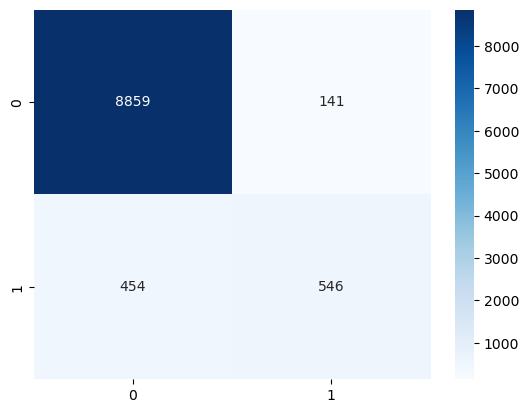

In [ ]:
# Create a confusion matrix, uses seaborn to show it.
def made_predictions(predictions):
    array = []
    for pred in predictions:
        if max(pred) > 0.7:
            array.append([1])
        else:
            array.append([0])
    return np.array(array)

y_pred_acc = acc_model.predict(x_test)
y_pred_acc = made_predictions(y_pred_acc)
acc_cf = confusion_matrix(y_test, y_pred_acc)

sns.heatmap(acc_cf, annot=True, cmap='Blues', fmt='d')
fig.savefig('./matplotlib_data/conf_mat_CNN')
fig.show()

313/313 - 1s - 4ms/step - accuracy: 0.9446 - loss: 0.2674


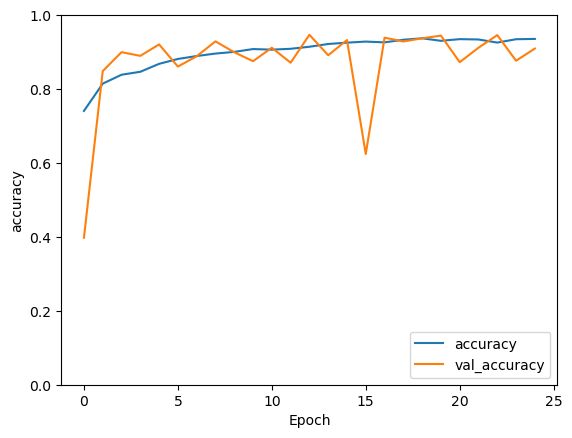

In [ ]:
# Create a graph to show overfitting and underfitting.
plt.plot(acc_history.history['accuracy'], label='accuracy')
plt.plot(acc_history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')
plt.savefig('./matplotlib_data/over_acc_CNN')

test_loss, test_acc = acc_model.evaluate(x_test, y_test, verbose=2)

#### Task 2b)

Found these pictures from Google:

* <u>Image 1</u>
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.wcs.org%2Fget-involved%2Fupdates%2Ffascinating-frogs&psig=AOvVaw28_HGqOe7S2sxjPK3bsI5N&ust=1744278715616000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCKDFld_WyowDFQAAAAAdAAAAABAE

* <u>Image 2</u> 
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.twinkl.pt%2Fteaching-wiki%2Ffrog&psig=AOvVaw0bdQuBJB9qO9gkRwCWvou-&ust=1744633397275000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCPCGuIGA1YwDFQAAAAAdAAAAABAE

* <u>Image 3</u>
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.nytimes.com%2Fwirecutter%2Freviews%2Fnew-dog-checklist%2F&psig=AOvVaw2ZPUsP1HTJbZhOYM2tqHPx&ust=1744633423068000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCND_iI6A1YwDFQAAAAAdAAAAABAE

* <u>Image 4</u>
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.goodwood.com%2Fgrr%2Ff1%2Fthe-nine-best-f1-cars-of-all-time%2F&psig=AOvVaw0_NSf08TH2_7ChAB8GfZhd&ust=1744633440992000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCNi76pWA1YwDFQAAAAAdAAAAABAE

Used Tensorflows own load_img to convert the pictures into the right size. Then we show them in the graph below.

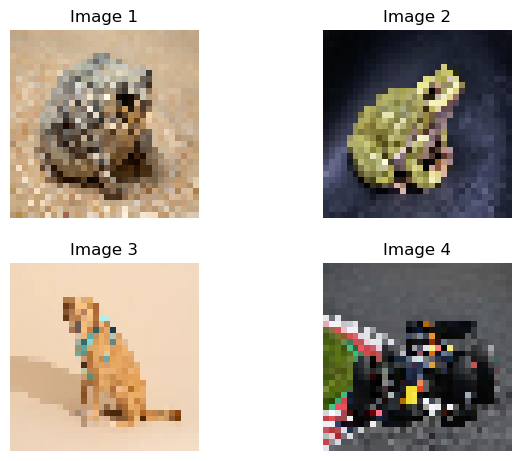

In [ ]:
# Showing the pictures we are using to test the models.
images = []

img_1 = tf.keras.utils.load_img('./media/frog_6.jpg', target_size=(32, 32))
img_2 = tf.keras.utils.load_img('./media/frog_4.jpg', target_size=(32, 32))
img_3 = tf.keras.utils.load_img('./media/dog_2.jpg', target_size=(32, 32))
img_4 = tf.keras.utils.load_img('./media/f1.jpg', target_size=(32, 32))

images.append(img_1)
images.append(img_2)
images.append(img_3)
images.append(img_4)

fig, ax = plt.subplots(2, 2)
fig.tight_layout()
ax = ax.flatten()

images_for_model = []
num = 1

for img, ax in zip(images, ax):
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.array(img_array) / 255.0 # Normalize
    images_for_model.append(img_array)
    ax.imshow(img_array)
    ax.set_title(f'Image {num}')
    ax.axis('off')
    num += 1

plt.show()

##### <u>Prediction</u>

When making our predictions we first add a batch to the picture so our model can actually use it to predict. When the model makes a prediction we convert it into a percentage for better reading. We add a threshold to decide if we are going to believe the model or not, we found that 70% worked nicely, print out the result.

In [ ]:
# Actual predictions
print("Hi! I'm Accuracy and I think that: ")
for num in range(len(images_for_model)):
    img = images_for_model[num]
    img = tf.expand_dims(img, 0) # Create a batch
    pred = acc_model.predict(img)
    pred = pred[0][0] * 100
    print(f"    Image {num + 1} is: ", end="")
    if pred > 70:
        print(f'{pred:.2f}% a frog.')
    else:
        print(f'{100 - pred:.2f}% not a frog')

Hi! I'm Accuracy and I think that: 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
    Image 1 is: 98.76% a frog.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
    Image 2 is: 99.94% a frog.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
    Image 3 is: 99.90% not a frog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
    Image 4 is: 99.21% not a frog


### Conclusion of task 2.

To summarize short we have create a binary CNN model to predict if a picture is a frog or not. In addition we have optimized most of our model through testing and created an optimal solution to the task. Lastly we also tested the model with pictures from the internet to test our model which worked quite nicely.